In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

ruta = "/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo"
os.chdir(ruta)

In [3]:
!pip install scikeras

In [4]:
!pip install --upgrade scikit-learn scikeras tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 34.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency reso

In [11]:
import random
import pandas as pd
import seaborn as sns
import joblib

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate

from keras.models import Sequential, load_model
from keras.layers import Dense, Flatten, Conv1D, MaxPooling1D
from scikeras.wrappers import KerasRegressor

import model_utils

from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# ==============================
# Configuración inicial
# ==============================

SEED = 7
random.seed(SEED)

# Proporciones del dataset
train_size = 0.8
test_size = 0.2

# ==============================
# Espacio de hiperparámetros
# ==============================

param_grid = {
    "optimizer": ["Adam"],
    "epochs": [30],
    "batch_size": [32],
    "model__filters": [16, 32],
    "model__kernel_size": [2, 3],
}

# ==============================
# Validación cruzada (Series temporales)
# ==============================

cv = TimeSeriesSplit(n_splits=10)

In [12]:
# ==============================
# Definición del modelo CNN
# ==============================

import tensorflow as tf

def build_cnn_model(optimizer="adam", init_mode="glorot_uniform", filters=32, kernel_size=3):

    tf.keras.backend.clear_session()  # 🔥 CLAVE

    model = Sequential()

    model.add(
        Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            kernel_initializer=init_mode,
            activation="relu",
            input_shape=(n_predictors, n_features),
        )
    )

    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation="relu"))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=filters * 2, kernel_size=kernel_size, activation="relu"))

    from keras.layers import GlobalAveragePooling1D, Dropout
    model.add(GlobalAveragePooling1D())
    model.add(Dropout(0.2))

    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))

    from keras.losses import MeanSquaredError
    model.compile(optimizer=optimizer, loss=MeanSquaredError())

    return model


# ==============================
# Wrapper compatible con Scikit-Learn
# ==============================

cnn_regressor = KerasRegressor(
    build_fn=build_cnn_model,
    verbose=0
)

In [13]:
df_7d_no_info = pd.read_csv(r'/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiario_7d_no_info.csv',parse_dates=["Fecha"], index_col=["Fecha"])


In [14]:
X_train_7d_no_info, X_test_7d_no_info, y_train_7d_no_info, y_test_7d_no_info = model_utils.split_train_test_deep(df_7d_no_info,
                                                train_size_=train_size,test_size_=test_size,
                                                target="m3(t)", _scale=True,verbose=False)

n_predictors = X_train_7d_no_info.shape[1]
n_features = 1

In [15]:
grid = GridSearchCV(estimator=cnn_regressor, param_grid=param_grid, n_jobs=1, cv=cv)

grid_result = grid.fit(X_train_7d_no_info, y_train_7d_no_info, callbacks=[early_stop], validation_split=0.2, verbose=1)

Epoch 1/30
3/3 - 11s - 4s/step - loss: 0.3312 - val_loss: 0.2947
Epoch 2/30
3/3 - 0s - 35ms/step - loss: 0.2756 - val_loss: 0.2416
Epoch 3/30
3/3 - 0s - 35ms/step - loss: 0.2267 - val_loss: 0.1853
Epoch 4/30
3/3 - 0s - 34ms/step - loss: 0.1730 - val_loss: 0.1307
Epoch 5/30
3/3 - 0s - 35ms/step - loss: 0.1206 - val_loss: 0.0826
Epoch 6/30
3/3 - 0s - 34ms/step - loss: 0.0759 - val_loss: 0.0441
Epoch 7/30
3/3 - 0s - 34ms/step - loss: 0.0505 - val_loss: 0.0212
Epoch 8/30
3/3 - 0s - 34ms/step - loss: 0.0306 - val_loss: 0.0171
Epoch 9/30
3/3 - 0s - 34ms/step - loss: 0.0282 - val_loss: 0.0244
Epoch 10/30
3/3 - 0s - 35ms/step - loss: 0.0323 - val_loss: 0.0281
Epoch 11/30
3/3 - 0s - 34ms/step - loss: 0.0333 - val_loss: 0.0266
Epoch 12/30
3/3 - 0s - 34ms/step - loss: 0.0294 - val_loss: 0.0216
Epoch 13/30
3/3 - 0s - 35ms/step - loss: 0.0247 - val_loss: 0.0179
Epoch 14/30
3/3 - 0s - 35ms/step - loss: 0.0235 - val_loss: 0.0174
Epoch 15/30
3/3 - 0s - 35ms/step - loss: 0.0309 - val_loss: 0.0184
Epoch

In [ ]:
best_conf = grid_result.best_params_
joblib.dump(best_conf, 'CNN_7d_no_info_normalizado_best_conf.pkl')

best_estimator = grid_result.best_estimator_
_7d_no_info_RMSE, _7d_no_info_MAE, _7d_no_info_MAPE = model_utils.crear_tabla_errores_cv_train(best_estimator,
                                                                                             X_train_7d_no_info,
                                                                                             y_train_7d_no_info,
                                                                                             cv,
                                                                                             '7 días sin información diaria')
joblib.dump(_7d_no_info_RMSE, 'CNN_7d_no_info_normalizado_RMSE_training.pkl')
joblib.dump(_7d_no_info_MAE, 'CNN_7d_no_info_normalizado_MAE_training.pkl')
joblib.dump(_7d_no_info_MAPE, 'CNN_7d_no_info_normalizado_MAPE_training.pkl')

predictor = best_estimator.model_
predictor.save('CNN_7d_no_info_normalizado_best_model.keras')

In [16]:
best_conf = joblib.load('CNN_7d_no_info_normalizado_best_conf.pkl')
best_conf

{'batch_size': 32,
 'epochs': 50,
 'model__filters': 64,
 'model__kernel_size': 2,
 'optimizer': 'Adam'}

In [17]:
_7d_no_info_RMSE = joblib.load('CNN_7d_no_info_normalizado_RMSE_training.pkl')
_7d_no_info_MAE = joblib.load('CNN_7d_no_info_normalizado_MAE_training.pkl')
_7d_no_info_MAPE = joblib.load('CNN_7d_no_info_normalizado_MAPE_training.pkl')


In [18]:
predictor_7d_no_info = load_model('CNN_7d_no_info_normalizado_best_model.keras')


37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


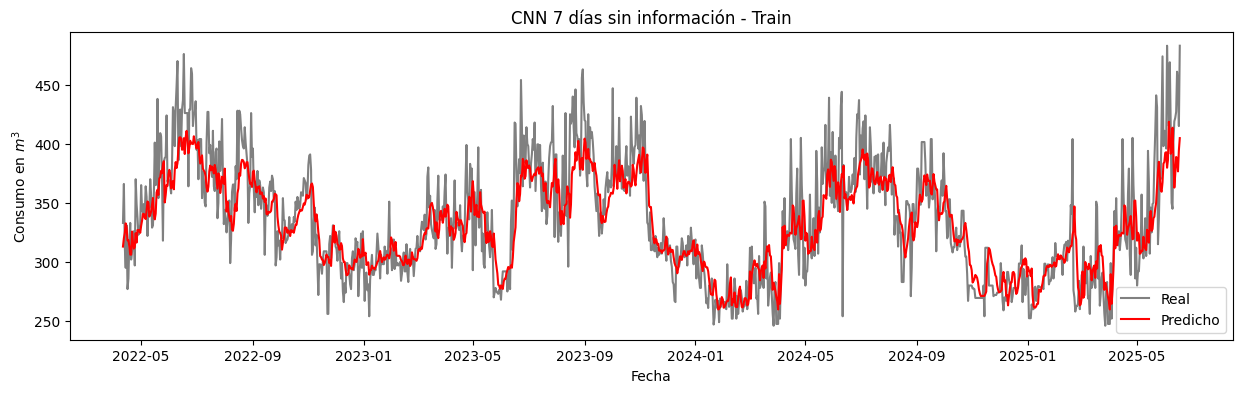

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


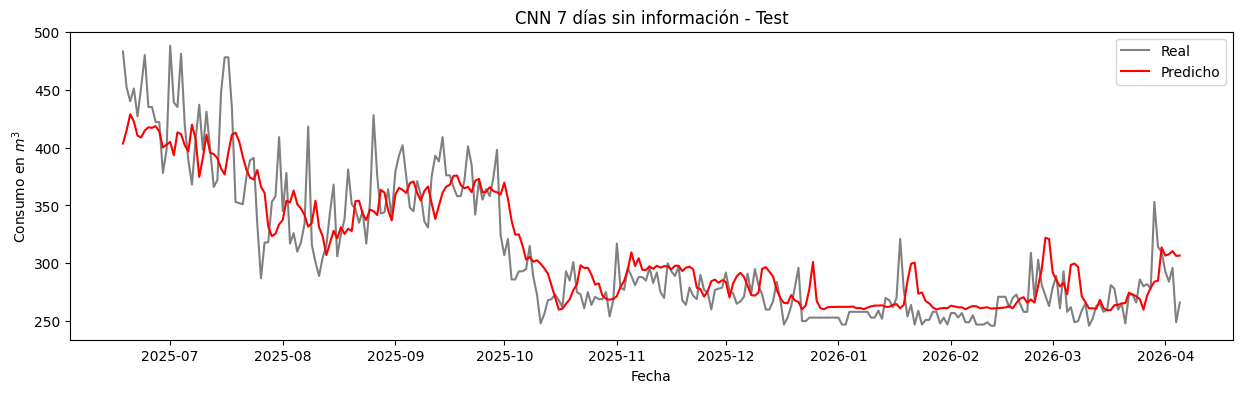

In [19]:
model_utils.grafica_resultado(predictor_7d_no_info,"CNN 7 días sin información", df_7d_no_info,
                            train_size,test_size,show_scaled=False)

In [20]:
model_utils.regression_results(y_test_7d_no_info, predictor_7d_no_info.predict(X_test_7d_no_info))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
r2: 0.79
MAE: 0.08
MSE: 0.01
RMSE: 0.12
MAPE (%): 32.71


In [21]:
df_7d_info = pd.read_csv(r'/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiario_7d_info.csv',parse_dates=["Fecha"], index_col=["Fecha"])


In [23]:
X_train_7d_info, X_test_7d_info, y_train_7d_info, y_test_7d_info = model_utils.split_train_test_deep(df_7d_info,
                                                train_size_=train_size,test_size_=test_size,
                                                target="m3(t)", _scale=True,verbose=False)

n_predictors = X_train_7d_info.shape[1]
n_features = 1

In [24]:

grid = GridSearchCV(estimator=cnn_regressor, param_grid=param_grid, n_jobs=1, cv=cv)

grid_result = grid.fit(X_train_7d_info, y_train_7d_info, callbacks=[early_stop], validation_split=0.2, verbose=1)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.1806 - val_loss: 0.1132
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1151 - val_loss: 0.0559
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0602 - val_loss: 0.0241
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0409 - val_loss: 0.0195
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0297 - val_loss: 0.0332
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0381 - val_loss: 0.0390
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0459 - val_loss: 0.0298
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0299 - val_loss: 0.0211
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0277 - val_loss: 0.0179
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0261 - val_loss: 0.0189
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0276 - val_loss: 0.0196
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0271 - val_loss: 0.0192
Epo

In [26]:
best_conf = grid_result.best_params_
joblib.dump(best_conf, 'CNN_7d_info_normalizado_best_conf.pkl')

best_estimator = grid_result.best_estimator_
_7d_info_RMSE, _7d_info_MAE, _7d_info_MAPE = model_utils.crear_tabla_errores_cv_train(best_estimator,
                                                                                         X_train_7d_info,
                                                                                         y_train_7d_info,
                                                                                         cv,
                                                                                         '7 días con información diaria')
joblib.dump(_7d_info_RMSE, 'CNN_7d_info_normalizado_RMSE_training.pkl')
joblib.dump(_7d_info_MAE, 'CNN_7d_info_normalizado_MAE_training.pkl')
joblib.dump(_7d_info_MAPE, 'CNN_7d_info_normalizado_MAPE_training.pkl')

predictor = best_estimator.model_
predictor.save('CNN_7d_info_normalizado_best_model.keras')

In [27]:

best_conf = joblib.load('CNN_7d_info_normalizado_best_conf.pkl')
best_conf

{'batch_size': 32,
 'epochs': 30,
 'model__filters': 16,
 'model__kernel_size': 3,
 'optimizer': 'Adam'}

In [28]:
_7d_info_RMSE = joblib.load('CNN_7d_info_normalizado_RMSE_training.pkl')
_7d_info_MAE = joblib.load('CNN_7d_info_normalizado_MAE_training.pkl')
_7d_info_MAPE = joblib.load('CNN_7d_info_normalizado_MAPE_training.pkl')

In [29]:
predictor_7d_info = load_model('CNN_7d_info_normalizado_best_model.keras')


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


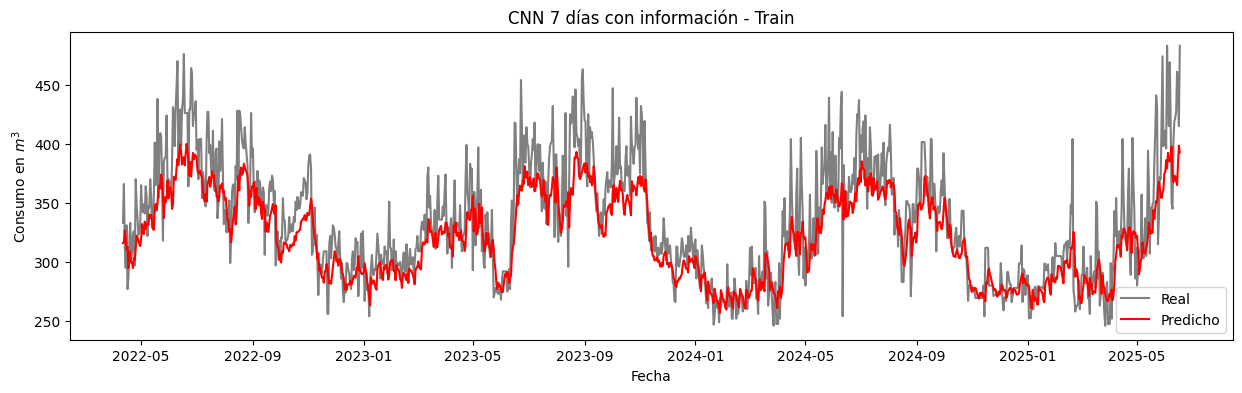

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step


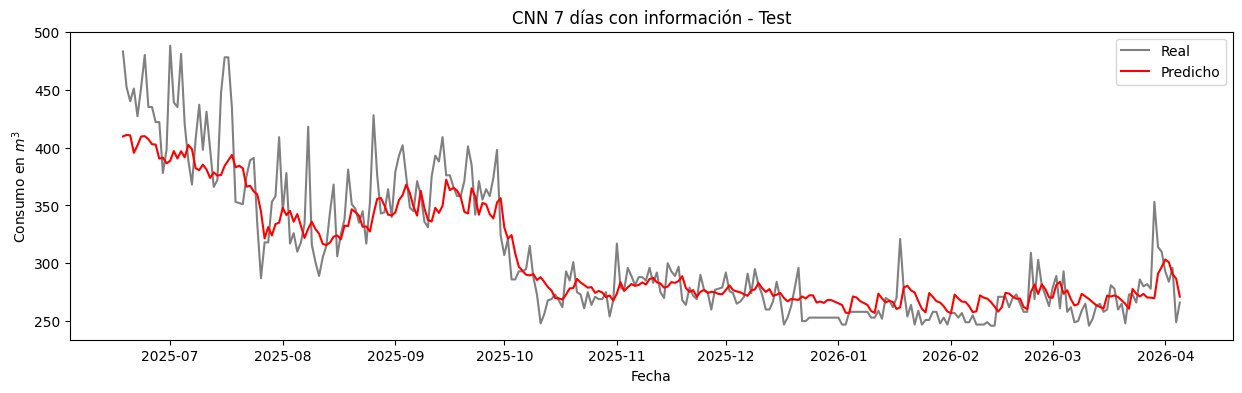

In [30]:

model_utils.grafica_resultado(predictor_7d_info,"CNN 7 días con información", df_7d_info,
                            train_size,test_size,show_scaled=False)

In [31]:
model_utils.regression_results(y_test_7d_info, predictor_7d_info.predict(X_test_7d_info))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
r2: 0.82
MAE: 0.08
MSE: 0.01
RMSE: 0.11
MAPE (%): 28.97


In [32]:
df_14d_no_info = pd.read_csv(r'/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiario_14d_no_info.csv',parse_dates=["Fecha"], index_col=["Fecha"])


In [33]:
X_train_14d_no_info, X_test_14d_no_info, y_train_14d_no_info, y_test_14d_no_info = model_utils.split_train_test_deep(df_14d_no_info,
                                                train_size_=train_size,test_size_=test_size,
                                                target="m3(t)", _scale=True,verbose=False)

n_predictors = X_train_14d_no_info.shape[1]
n_features = 1

In [34]:
grid = GridSearchCV(estimator=cnn_regressor, param_grid=param_grid, n_jobs=1, cv=cv)

grid_result = grid.fit(X_train_14d_no_info, y_train_14d_no_info, callbacks=[early_stop], validation_split=0.2, verbose=1)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 0.3902 - val_loss: 0.2790
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.3284 - val_loss: 0.2268
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2706 - val_loss: 0.1805
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2210 - val_loss: 0.1460
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1802 - val_loss: 0.1143
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1440 - val_loss: 0.0842
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1105 - val_loss: 0.0568
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0856 - val_loss: 0.0346
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0598 - val_loss: 0.0198
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0404 - val_loss: 0.0147
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0255 - val_loss: 0.0180
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0353 - val_loss: 0.0260
Epo

In [35]:
best_conf = grid_result.best_params_
joblib.dump(best_conf, 'CNN_14d_no_info_normalizado_best_conf.pkl')

best_estimator = grid_result.best_estimator_
_14d_no_info_RMSE, _14d_no_info_MAE, _14d_no_info_MAPE = model_utils.crear_tabla_errores_cv_train(best_estimator,
                                                                                                X_train_14d_no_info,
                                                                                                y_train_14d_no_info,
                                                                                                cv,
                                                                                            '14 días sin información diaria')
joblib.dump(_14d_no_info_RMSE, 'CNN_14d_no_info_normalizado_RMSE_training.pkl')
joblib.dump(_14d_no_info_MAE, 'CNN_14d_no_info_normalizado_MAE_training.pkl')
joblib.dump(_14d_no_info_MAPE, 'CNN_14d_no_info_normalizado_MAPE_training.pkl')

predictor = best_estimator.model_
predictor.save('CNN_14d_no_info_normalizado_best_model.keras')

In [36]:
best_conf = joblib.load('CNN_14d_no_info_normalizado_best_conf.pkl')
best_conf

{'batch_size': 32,
 'epochs': 30,
 'model__filters': 32,
 'model__kernel_size': 3,
 'optimizer': 'Adam'}

In [37]:
_14d_no_info_RMSE = joblib.load('CNN_14d_no_info_normalizado_RMSE_training.pkl')
_14d_no_info_MAE = joblib.load('CNN_14d_no_info_normalizado_MAE_training.pkl')
_14d_no_info_MAPE = joblib.load('CNN_14d_no_info_normalizado_MAPE_training.pkl')


In [38]:
predictor_14d_no_info = load_model('CNN_14d_no_info_normalizado_best_model.keras')


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


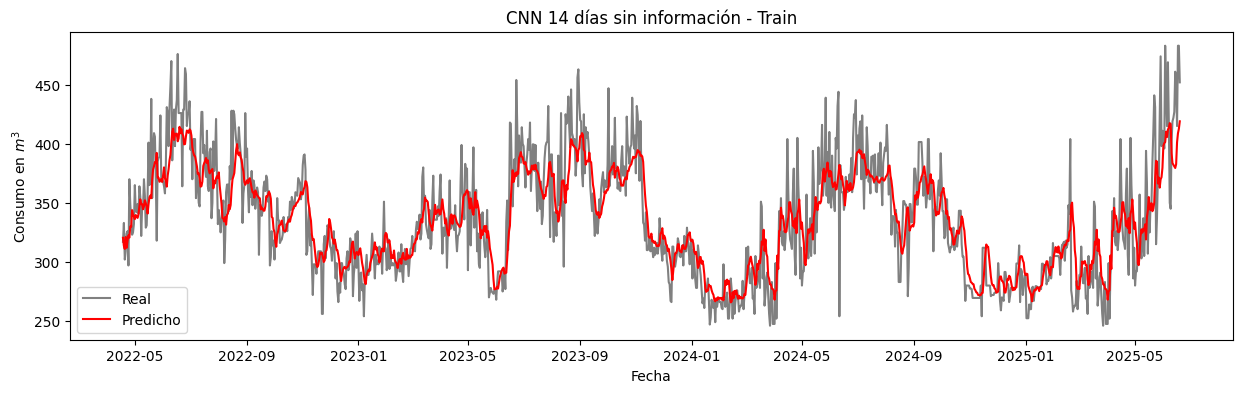

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step


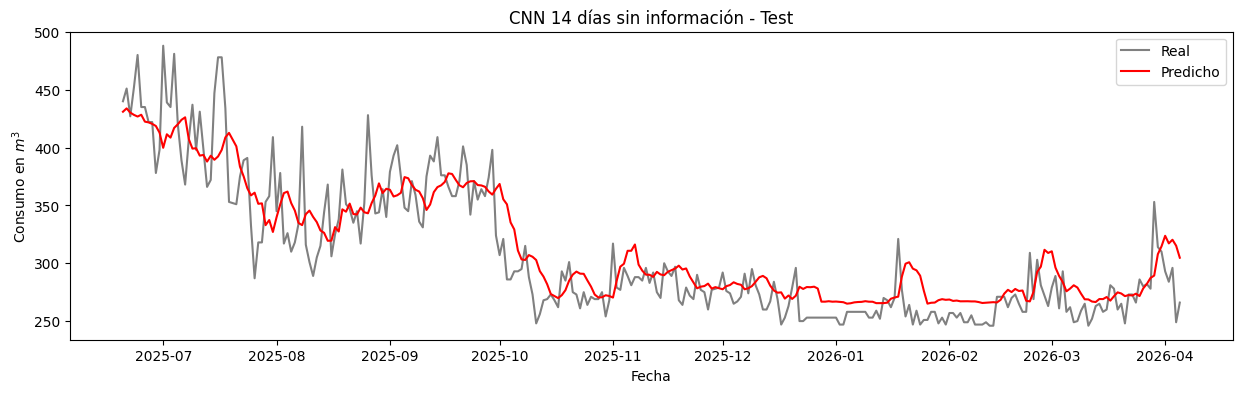

In [39]:
model_utils.grafica_resultado(predictor_14d_no_info,"CNN 14 días sin información", df_14d_no_info,
                            train_size,test_size,show_scaled=False)

In [40]:
model_utils.regression_results(y_test_14d_no_info, predictor_14d_no_info.predict(X_test_14d_no_info))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
r2: 0.79
MAE: 0.09
MSE: 0.01
RMSE: 0.11
MAPE (%): 33.32


In [41]:
df_14d_info = pd.read_csv(r'/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiario_14d_info.csv',parse_dates=["Fecha"], index_col=["Fecha"])


In [42]:
X_train_14d_info, X_test_14d_info, y_train_14d_info, y_test_14d_info = model_utils.split_train_test_deep(df_14d_info,
                                                train_size_=train_size,test_size_=test_size,
                                                target="m3(t)", _scale=True,verbose=False)

n_predictors = X_train_14d_info.shape[1]
n_features = 1

In [43]:
grid = GridSearchCV(estimator=cnn_regressor, param_grid=param_grid, n_jobs=1, cv=cv)

grid_result = grid.fit(X_train_14d_info, y_train_14d_info, callbacks=[early_stop], validation_split=0.2, verbose=1)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.3340 - val_loss: 0.2227
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.2578 - val_loss: 0.1606
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1951 - val_loss: 0.1036
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1373 - val_loss: 0.0576
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0846 - val_loss: 0.0270
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0436 - val_loss: 0.0152
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0284 - val_loss: 0.0214
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0208 - val_loss: 0.0374
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0335 - val_loss: 0.0481
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0345 - val_loss: 0.0455
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0300 - val_loss: 0.0347
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0218 - val_loss: 0.0259
Ep

In [44]:
best_conf = grid_result.best_params_
joblib.dump(best_conf, 'CNN_14d_info_normalizado_best_conf.pkl')

best_estimator = grid_result.best_estimator_
_14d_info_RMSE, _14d_info_MAE, _14d_info_MAPE = model_utils.crear_tabla_errores_cv_train(best_estimator,
                                                                                       X_train_14d_info,
                                                                                       y_train_14d_info,
                                                                                       cv,
                                                                                       '14 días con información diaria')
joblib.dump(_14d_info_RMSE, 'CNN_14d_info_normalizado_RMSE_training.pkl')
joblib.dump(_14d_info_MAE, 'CNN_14d_info_normalizado_MAE_training.pkl')
joblib.dump(_14d_info_MAPE, 'CNN_14d_info_normalizado_MAPE_training.pkl')

predictor = best_estimator.model_
predictor.save('CNN_14d_info_normalizado_best_model.keras')

In [45]:

best_conf = joblib.load('CNN_14d_info_normalizado_best_conf.pkl')
best_conf

{'batch_size': 32,
 'epochs': 30,
 'model__filters': 32,
 'model__kernel_size': 3,
 'optimizer': 'Adam'}

In [46]:

_14d_info_RMSE = joblib.load('CNN_14d_info_normalizado_RMSE_training.pkl')
_14d_info_MAE = joblib.load('CNN_14d_info_normalizado_MAE_training.pkl')
_14d_info_MAPE = joblib.load('CNN_14d_info_normalizado_MAPE_training.pkl')

In [47]:
predictor_14d_info = load_model('CNN_14d_info_normalizado_best_model.keras')


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


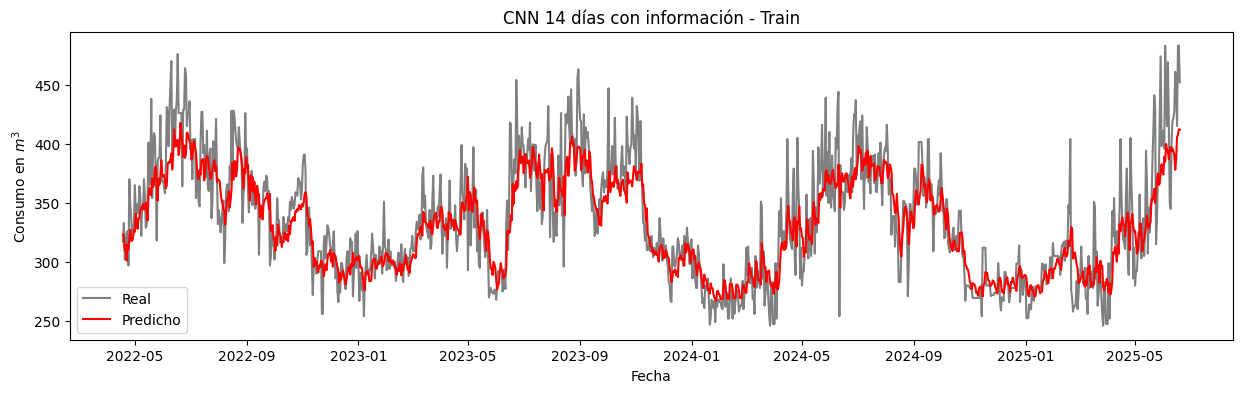

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step


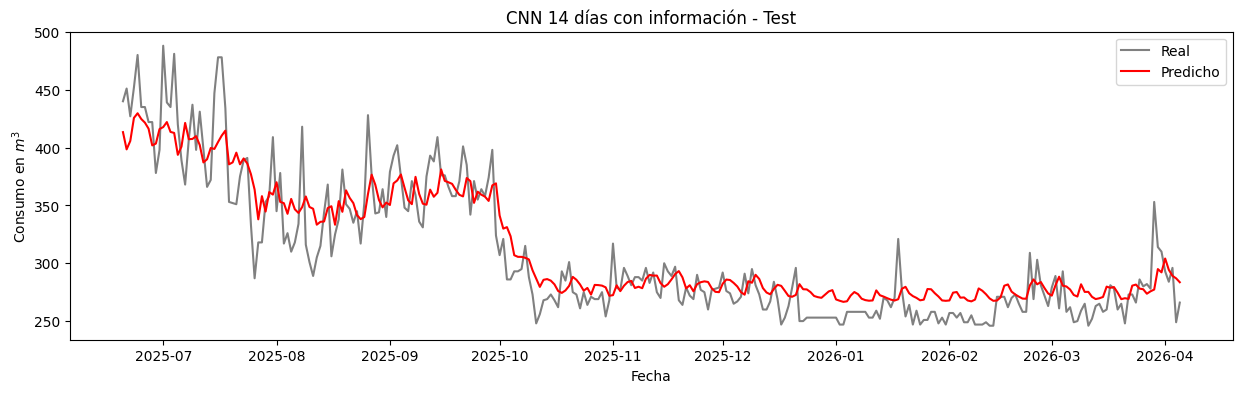

In [48]:
model_utils.grafica_resultado(predictor_14d_info,"CNN 14 días con información", df_14d_info,
                            train_size,test_size,show_scaled=False)

In [49]:
model_utils.regression_results(y_test_14d_info, predictor_14d_info.predict(X_test_14d_info))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
r2: 0.84
MAE: 0.08
MSE: 0.01
RMSE: 0.1
MAPE (%): 30.25


In [50]:
errores_training_rmse = pd.concat([_7d_no_info_RMSE, _7d_info_RMSE, _14d_no_info_RMSE, _14d_info_RMSE], axis=1)
errores_training_rmse

,7 días sin información diaria,7 días con información diaria,14 días sin información diaria,14 días con información diaria
0,0.105662,0.121704,0.123409,0.133970
1,0.083096,0.078388,0.088315,0.082332
2,0.108712,0.099204,0.111582,0.102407
3,0.144787,0.134115,0.138442,0.137162
4,0.097654,0.105259,0.089360,0.108855
5,0.115280,0.116427,0.111341,0.107106
6,0.146624,0.126337,0.140251,0.130139
7,0.108308,0.098946,0.101387,0.093167
8,0.088840,0.074867,0.088732,0.080497
9,0.151545,0.146675,0.153015,0.148599


In [61]:
errores_training_rmse.to_csv("/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/CNN_rmse_training.csv")


[Text(0.5, 0, 'Dataset utilizado'), Text(0, 0.5, 'RMSE')]

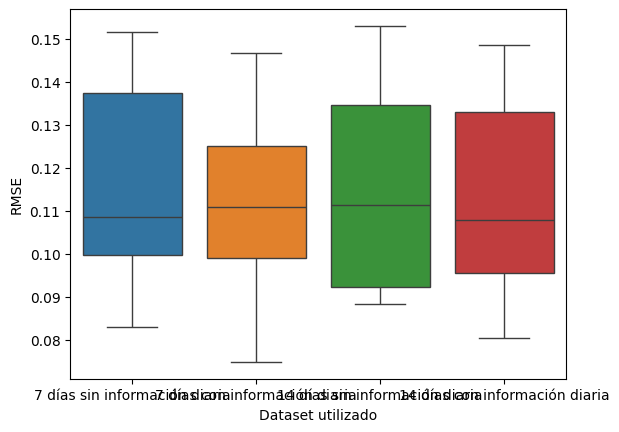

In [52]:
sns.boxplot(data=errores_training_rmse).set(xlabel='Dataset utilizado', ylabel='RMSE')


In [53]:

errores_training_mae = pd.concat([_7d_no_info_MAE, _7d_info_MAE, _14d_no_info_MAE, _14d_info_MAE], axis=1)
errores_training_mae

,7 días sin información diaria,7 días con información diaria,14 días sin información diaria,14 días con información diaria
0,0.059875,0.071581,0.072919,0.077839
1,0.050975,0.053845,0.053903,0.050295
2,0.061653,0.062778,0.059059,0.064607
3,0.076958,0.090607,0.084685,0.091764
4,0.050448,0.056266,0.052715,0.061805
5,0.086513,0.094403,0.089143,0.076459
6,0.086682,0.074731,0.083668,0.083850
7,0.075966,0.064057,0.063214,0.053287
8,0.043149,0.036725,0.037693,0.038175
9,0.088429,0.089529,0.092139,0.092289


In [60]:
errores_training_mae.to_csv("/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/CNN_mae_training.csv")


[Text(0.5, 0, 'Dataset utilizado'), Text(0, 0.5, 'MAE')]

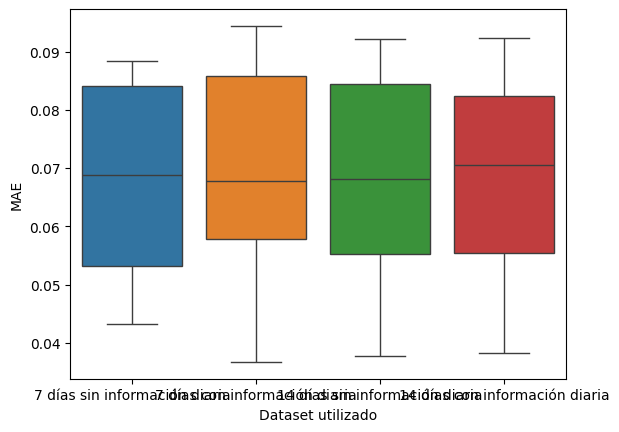

In [55]:
sns.boxplot(data=errores_training_mae).set(xlabel='Dataset utilizado', ylabel='MAE')


In [56]:

errores_training_mape = pd.concat([_7d_no_info_MAPE, _7d_info_MAPE, _14d_no_info_MAPE, _14d_info_MAPE], axis=1)
errores_training_mape

,7 días sin información diaria,7 días con información diaria,14 días sin información diaria,14 días con información diaria
0,24.092698,29.254243,29.272776,33.539116
1,29.567893,27.949013,32.344475,29.334220
2,27.580844,28.444481,27.350587,27.141037
3,20.902293,18.685498,20.544813,21.490860
4,21.244383,18.492979,19.181062,20.429283
5,35.387349,42.120502,38.915373,35.750348
6,26.211708,21.827889,22.466641,20.366075
7,30.490377,29.780058,29.352880,22.950012
8,30.868187,25.614417,22.627001,22.968502
9,34.108728,29.776780,30.154549,30.231491


In [59]:
errores_training_mape.to_csv("/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/CNN_mape_training.csv")


[Text(0.5, 0, 'Dataset utilizado'), Text(0, 0.5, 'MAPE')]

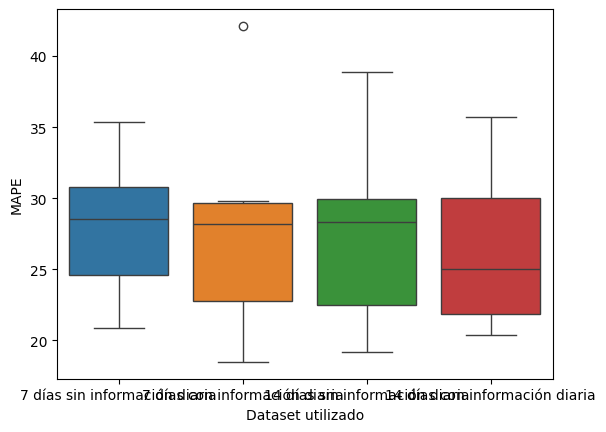

In [58]:
sns.boxplot(data=errores_training_mape).set(xlabel='Dataset utilizado', ylabel='MAPE')
